# 3 - Parallel mechanism jobs, diverse batches, and Chronos-2

## Abstract

This experiment connects random symbolic mechanisms to model evaluation. Each parallel job samples one canonical abstract syntax tree (AST), binds its coefficients and lags, rejects unstable candidates, and generates several independent trajectories from the accepted mechanism. A diversity-aware batch builder then guarantees that the forecasting batch contains at least a configured number of distinct AST skeletons. The retained past of every trajectory is supplied to Chronos-2, while the formula, mechanism identity, and held-out future remain outside the model input and are used only for traceability and evaluation. The experiment reports generation reproducibility, batch composition, zero-shot forecast errors, a last-value baseline, and mechanism-level results.

The expression-first direction follows D'Ascoli et al., [*Deep Symbolic Regression for Recurrent Sequences*](https://proceedings.mlr.press/v162/d-ascoli22a.html). Chronos-2 is invoked through the dataframe API documented in the [official Amazon repository](https://github.com/amazon-science/chronos-forecasting) and implemented by [`Chronos2Pipeline.predict_df`](https://github.com/amazon-science/chronos-forecasting/blob/main/src/chronos/chronos2/pipeline.py).

## Pipeline represented in this notebook

```text
job 0 -> AST 0 -> trajectory 0.0, trajectory 0.1, ...
job 1 -> AST 1 -> trajectory 1.0, trajectory 1.1, ...
job 2 -> AST 2 -> trajectory 2.0, trajectory 2.1, ...
  ...         (jobs may execute in any order)
                   |
                   v
diversity-aware batch: at least K distinct AST skeletons
                   |
        +----------+-----------+
        |                      |
        v                      v
past values -> Chronos-2    held-out future -> evaluation only
```

The seed of a candidate is derived from `(root seed, job index, attempt index, stream)`. Therefore worker scheduling can change without changing the indexed result.

**Independence from the calling program.** The generator creates local NumPy
random generators from the explicit root seed and derives separate streams from
the job index, candidate attempt, and stream role. It neither reads nor changes
the global states controlled by `random.seed()` or `numpy.random.seed()` in the
user's program. Consequently, fixed generator configuration, root seed, library
version, and numerical backend determine the generated examples; `n_jobs`
changes scheduling only. These guarantees are checked automatically in
`tests/unit/test_parallel_batch.py`.

## 1. Imports and complete configuration

In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import importlib.metadata
import json
import os
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parents[1]
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.datasets import (
    ParallelGenerationConfig,
    assemble_diverse_batch,
    generate_mechanism_jobs,
)
from tsfmxai.generators import RandomTreeConfig

ROOT_SEED = 20260929
N_JOBS = min(4, os.cpu_count() or 1)
BATCH_SIZE = 16
MINIMUM_DISTINCT_MECHANISMS = 4

TREE_CONFIG = RandomTreeConfig(
    minimum_operators=1,
    maximum_operators=3,
    num_series=1,
    minimum_lag=1,
    maximum_lag=12,
    parameter_probability=0.55,
    time_probability=0.0,
    lag_probability=0.45,
    add_probability=0.80,
    minimum_parameter_magnitude=0.05,
    maximum_parameter_magnitude=0.80,
    require_lag=True,
    require_time=False,
)

GENERATION_CONFIG = ParallelGenerationConfig(
    job_count=8,
    trajectories_per_job=4,
    context_length=96,
    prediction_length=16,
    burn_in=48,
    innovation_std=0.05,
    initial_value_minimum=-1.0,
    initial_value_maximum=1.0,
    maximum_absolute_value=100.0,
    minimum_window_std=1e-4,
    maximum_attempts_per_job=100,
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Available logical CPUs: {os.cpu_count()}")
print(f"Parallel workers requested: {N_JOBS}")
print(json.dumps({
    "root_seed": ROOT_SEED,
    "batch_size": BATCH_SIZE,
    "minimum_distinct_mechanisms": MINIMUM_DISTINCT_MECHANISMS,
    "tree": asdict(TREE_CONFIG),
    "generation": asdict(GENERATION_CONFIG),
}, indent=2))

Project root: C:\Users\mateu\repos\tsfmxai
Available logical CPUs: 8
Parallel workers requested: 4
{
  "root_seed": 20260929,
  "batch_size": 16,
  "minimum_distinct_mechanisms": 4,
  "tree": {
    "minimum_operators": 1,
    "maximum_operators": 3,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
    "lag_probability": 0.45,
    "add_probability": 0.8,
    "minimum_parameter_magnitude": 0.05,
    "maximum_parameter_magnitude": 0.8,
    "require_lag": true,
    "require_time": false
  },
  "generation": {
    "job_count": 8,
    "trajectories_per_job": 4,
    "context_length": 96,
    "prediction_length": 16,
    "burn_in": 48,
    "innovation_std": 0.05,
    "initial_value_minimum": -1.0,
    "initial_value_maximum": 1.0,
    "maximum_absolute_value": 100.0,
    "minimum_window_std": 0.0001,
    "maximum_attempts_per_job": 100
  }
}


**What this cell did.** It imported the reusable project modules and fixed every random-generation, window, diversity, and worker parameter used below. Time terminals are disabled in this first batching experiment so the test isolates lagged recurrences.

## 2. Run one mechanism-and-trajectories task per parallel job

In [2]:
parallel_started = time.perf_counter()
job_results = generate_mechanism_jobs(
    TREE_CONFIG,
    GENERATION_CONFIG,
    root_seed=ROOT_SEED,
    n_jobs=N_JOBS,
    backend="loky",
)
parallel_generation_seconds = time.perf_counter() - parallel_started

job_summary = pd.DataFrame(
    [
        {
            "job": result.job_index,
            "accepted_attempt": result.attempt_index,
            "mechanism_seed": result.mechanism_seed,
            "trajectory_seed": result.trajectory_seed,
            "trajectory_count": len(result.trajectories),
            "skeleton": result.mechanism.skeleton_formula,
            "bound_formula": result.mechanism.formula,
            "maximum_abs_value": float(np.max(np.abs(result.trajectories))),
        }
        for result in job_results
    ]
)

print(f"Generated {len(job_results)} accepted jobs in {parallel_generation_seconds:.3f} s.")
display(job_summary)

Generated 8 accepted jobs in 0.531 s.


,job,accepted_attempt,mechanism_seed,trajectory_seed,trajectory_count,skeleton,bound_formula,maximum_abs_value
0,0,0,1424776893210911713,3767882738720183124,4,"((LAG(0, L0) + P0) + P1)",((x_0(t-7) + 0.621851) + 0.1734),19.435724
1,1,0,10885231728690395407,3387665606732895856,4,"(LAG(0, L0) + (P0 * P1))",(x_0(t-4) + (0.657414 * 0.122342)),4.519009
2,2,0,6245163068482373554,16864640935861044090,4,"(LAG(0, L0) + P0)",(x_0(t-11) + 0.396507),6.931297
3,3,0,5062606768475584129,18384635666198322270,4,"(LAG(0, L0) + P0)",(x_0(t-5) + 0.133949),5.389249
4,4,0,4005806404350946089,5942319063880517004,4,"(LAG(0, L0) + P0)",(x_0(t-9) + 0.698905),13.807339
5,5,0,2290870753248771690,2316979523151446230,4,"(LAG(0, L0) + (P0 * P1))",(x_0(t-5) + (0.162533 * 0.738036)),4.900658
6,6,0,2567859428136471077,11283138407654903370,4,"((LAG(0, L0) + P0) + (P1 + P2))",((x_0(t-1) + -0.324739) + (0.710897 + -0.699881)),50.839407
7,7,2,11700719166444979095,1953313553516415809,4,"(LAG(0, L0) + P0)",(x_0(t-2) + 0.73527),59.511194


**What this cell did.** It dispatched eight independent jobs through joblib's process-based `loky` backend. Each row is one accepted tree; all four trajectories in that row share the displayed mechanism but have independently sampled initial conditions and Gaussian innovations.

In [3]:
sequential_started = time.perf_counter()
sequential_results = generate_mechanism_jobs(
    TREE_CONFIG,
    GENERATION_CONFIG,
    root_seed=ROOT_SEED,
    n_jobs=1,
)
sequential_generation_seconds = time.perf_counter() - sequential_started

same_mechanisms = all(
    parallel.mechanism == sequential.mechanism
    for parallel, sequential in zip(job_results, sequential_results)
)
same_trajectories = all(
    np.array_equal(parallel.trajectories, sequential.trajectories)
    for parallel, sequential in zip(job_results, sequential_results)
)
assert same_mechanisms and same_trajectories

print({
    "same_mechanisms": same_mechanisms,
    "same_trajectories": same_trajectories,
    "parallel_seconds": round(parallel_generation_seconds, 4),
    "sequential_seconds": round(sequential_generation_seconds, 4),
    "observed_speedup": round(sequential_generation_seconds / parallel_generation_seconds, 3),
})

{'same_mechanisms': True, 'same_trajectories': True, 'parallel_seconds': 0.5309, 'sequential_seconds': 0.0404, 'observed_speedup': 0.076}


**What this cell did.** It reran the same indexed jobs sequentially and verified exact equality of both mechanisms and floating-point trajectories. The timing is descriptive for this small experiment; process startup can dominate such lightweight jobs, so it is not treated as a general performance conclusion.

## 3. Assemble a batch with a minimum number of different mechanisms

In [4]:
batch = assemble_diverse_batch(
    job_results,
    GENERATION_CONFIG,
    batch_size=BATCH_SIZE,
    minimum_distinct_mechanisms=MINIMUM_DISTINCT_MECHANISMS,
)

assert batch.past_values.shape == (BATCH_SIZE, GENERATION_CONFIG.context_length)
assert batch.future_values.shape == (BATCH_SIZE, GENERATION_CONFIG.prediction_length)
assert batch.distinct_mechanism_count >= MINIMUM_DISTINCT_MECHANISMS

composition = (
    pd.DataFrame({
        "series_id": batch.series_ids,
        "mechanism_id": batch.mechanism_ids,
        "job": batch.job_indices,
        "trajectory": batch.trajectory_indices,
        "skeleton": batch.skeletons,
        "formula": batch.formulas,
    })
    .groupby(["mechanism_id", "job", "skeleton", "formula"], as_index=False)
    .agg(trajectories_in_batch=("trajectory", "count"))
)

print({
    "batch_shape_past": batch.past_values.shape,
    "batch_shape_future": batch.future_values.shape,
    "distinct_skeletons": batch.distinct_mechanism_count,
    "required_distinct_skeletons": MINIMUM_DISTINCT_MECHANISMS,
})
display(composition)

{'batch_shape_past': (16, 96), 'batch_shape_future': (16, 16), 'distinct_skeletons': 4, 'required_distinct_skeletons': 4}


,mechanism_id,job,skeleton,formula,trajectories_in_batch
0,mechanism_0000,0,"((LAG(0, L0) + P0) + P1)",((x_0(t-7) + 0.621851) + 0.1734),4
1,mechanism_0001,1,"(LAG(0, L0) + (P0 * P1))",(x_0(t-4) + (0.657414 * 0.122342)),4
2,mechanism_0002,2,"(LAG(0, L0) + P0)",(x_0(t-11) + 0.396507),4
3,mechanism_0006,6,"((LAG(0, L0) + P0) + (P1 + P2))",((x_0(t-1) + -0.324739) + (0.710897 + -0.699881)),4


**What this cell did.** It selected trajectories in round-robin order across unique AST skeletons. The assertion is the batch contract: a batch is rejected when the requested number of structurally different mechanisms cannot be represented.

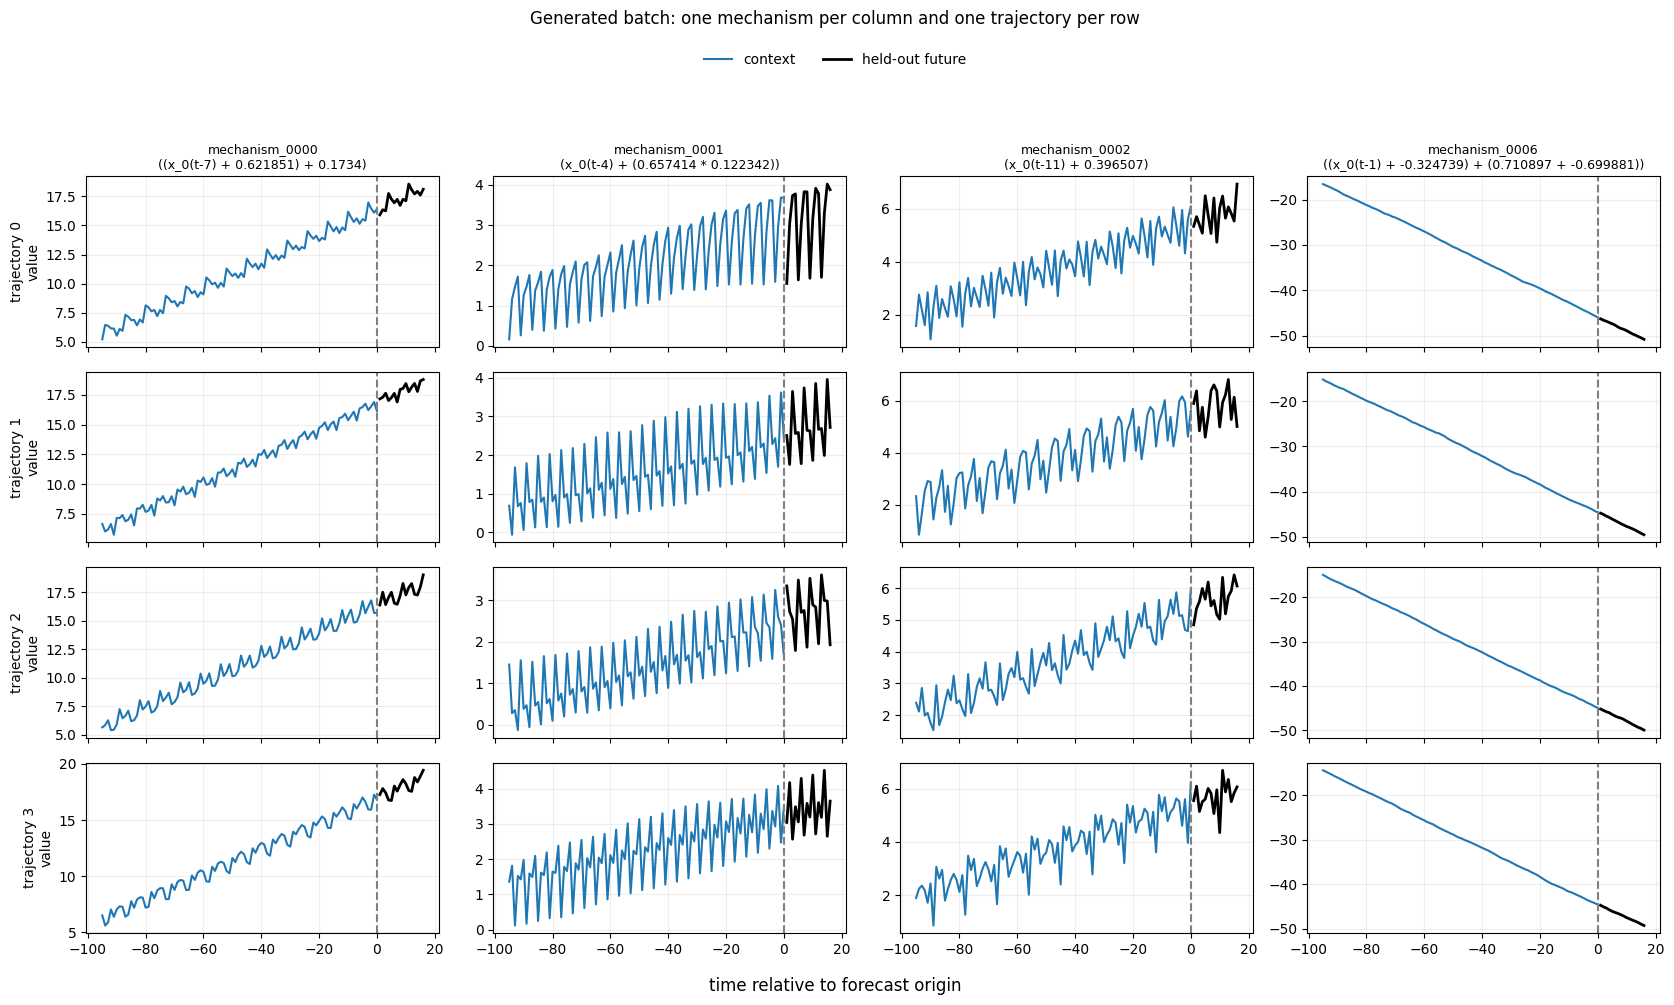

In [5]:
mechanism_order = list(dict.fromkeys(batch.mechanism_ids))
trajectory_order = sorted(set(int(value) for value in batch.trajectory_indices))
batch_position = {
    (mechanism_id, int(trajectory_index)): index
    for index, (mechanism_id, trajectory_index) in enumerate(
        zip(batch.mechanism_ids, batch.trajectory_indices)
    )
}

context_axis = np.arange(-GENERATION_CONFIG.context_length + 1, 1)
future_axis = np.arange(1, GENERATION_CONFIG.prediction_length + 1)
fig, axes = plt.subplots(
    len(trajectory_order),
    len(mechanism_order),
    figsize=(4.2 * len(mechanism_order), 2.5 * len(trajectory_order)),
    squeeze=False,
    sharex=True,
)

for row, trajectory_index in enumerate(trajectory_order):
    for column, mechanism_id in enumerate(mechanism_order):
        axis = axes[row, column]
        position = batch_position.get((mechanism_id, trajectory_index))
        if position is None:
            axis.axis("off")
            continue

        axis.plot(context_axis, batch.past_values[position], label="context")
        axis.plot(
            future_axis,
            batch.future_values[position],
            color="black",
            linewidth=2,
            label="held-out future",
        )
        axis.axvline(0, color="0.5", linestyle="--")
        axis.grid(alpha=0.2)
        if row == 0:
            axis.set_title(
                f"{mechanism_id}\n{batch.formulas[position]}",
                fontsize=9,
            )
        if column == 0:
            axis.set_ylabel(f"trajectory {trajectory_index}\nvalue")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=2,
    frameon=False,
)
fig.suptitle(
    "Generated batch: one mechanism per column and one trajectory per row",
    y=0.995,
)
fig.supxlabel("time relative to forecast origin")
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

**What this cell did.** It displayed every series in the forecasting batch. Columns keep the symbolic mechanism fixed, while rows change the initial conditions and Gaussian innovations that produce independent trajectories. The dashed boundary separates model context from the held-out future.

## 4. Construct exactly the input received by Chronos-2

Chronos-2 receives one long-format dataframe containing only:

- the series identifier required to keep batch rows separate;
- an artificial regular hourly timestamp;
- the 96 historical target values.

The AST, formula, job index, coefficients, lags, innovations, and 16 future values are deliberately excluded from `context_df`. They remain benchmark metadata or evaluation targets.

In [6]:
context_timestamps = pd.date_range(
    "2026-01-01",
    periods=GENERATION_CONFIG.context_length,
    freq="h",
)
context_df = pd.concat(
    [
        pd.DataFrame({
            "item_id": series_id,
            "timestamp": context_timestamps,
            "target": values,
        })
        for series_id, values in zip(batch.series_ids, batch.past_values)
    ],
    ignore_index=True,
)

assert list(context_df.columns) == ["item_id", "timestamp", "target"]
assert len(context_df) == BATCH_SIZE * GENERATION_CONFIG.context_length

print(f"Chronos-2 dataframe shape: {context_df.shape}")
print(f"Series received by the model: {context_df['item_id'].nunique()}")
display(context_df.head(8))

Chronos-2 dataframe shape: (1536, 3)
Series received by the model: 16


,item_id,timestamp,target
0,mechanism_0000_trajectory_000,2026-01-01 00:00:00,5.214249
1,mechanism_0000_trajectory_000,2026-01-01 01:00:00,6.452496
2,mechanism_0000_trajectory_000,2026-01-01 02:00:00,6.376940
3,mechanism_0000_trajectory_000,2026-01-01 03:00:00,6.154618
4,mechanism_0000_trajectory_000,2026-01-01 04:00:00,6.137635
5,mechanism_0000_trajectory_000,2026-01-01 05:00:00,5.527619
6,mechanism_0000_trajectory_000,2026-01-01 06:00:00,6.106798
7,mechanism_0000_trajectory_000,2026-01-01 07:00:00,5.944393


**What this cell did.** It translated the canonical batch to the official Chronos-2 dataframe interface. The displayed columns make the information boundary auditable: the model sees target history, not the generator that produced it.

## 5. Run zero-shot Chronos-2 forecasting

In [7]:
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")

import torch
from chronos import Chronos2Pipeline

MODEL_ID = "amazon/chronos-2"
DEVICE = "cpu"

load_started = time.perf_counter()
pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,
    device_map=DEVICE,
    dtype=torch.float32,
)
model_load_seconds = time.perf_counter() - load_started

print({
    "model_id": MODEL_ID,
    "device": DEVICE,
    "dtype": "float32",
    "load_seconds": round(model_load_seconds, 3),
})

{'model_id': 'amazon/chronos-2', 'device': 'cpu', 'dtype': 'float32', 'load_seconds': 1.241}


**What this cell did.** It loaded the official 120M-parameter Chronos-2 checkpoint in full precision on CPU. No fitting or fine-tuning on the generated trajectories is performed, so the following result is a zero-shot forecast.

In [8]:
forecast_started = time.perf_counter()
forecast_df = pipeline.predict_df(
    context_df,
    prediction_length=GENERATION_CONFIG.prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],
    id_column="item_id",
    timestamp_column="timestamp",
    target="target",
    batch_size=8,
)
chronos_inference_seconds = time.perf_counter() - forecast_started

def forecast_matrix(column: str) -> np.ndarray:
    return np.stack(
        [
            forecast_df.loc[forecast_df["item_id"].eq(series_id)]
            .sort_values("timestamp")[column]
            .to_numpy(dtype=float)
            for series_id in batch.series_ids
        ]
    )

chronos_prediction = forecast_matrix("predictions")
chronos_lower = forecast_matrix("0.1")
chronos_upper = forecast_matrix("0.9")
naive_prediction = np.repeat(batch.past_values[:, -1:], GENERATION_CONFIG.prediction_length, axis=1)

def row_metrics(prediction: np.ndarray, model_name: str) -> pd.DataFrame:
    error = prediction - batch.future_values
    scale = np.mean(np.abs(np.diff(batch.past_values, axis=1)), axis=1)
    scale = np.where(scale > 1e-12, scale, np.nan)
    return pd.DataFrame({
        "series_id": batch.series_ids,
        "mechanism_id": batch.mechanism_ids,
        "model": model_name,
        "MAE": np.mean(np.abs(error), axis=1),
        "RMSE": np.sqrt(np.mean(error**2, axis=1)),
        "MASE": np.mean(np.abs(error), axis=1) / scale,
    })

metric_rows = pd.concat(
    [
        row_metrics(chronos_prediction, "Chronos-2"),
        row_metrics(naive_prediction, "Last value"),
    ],
    ignore_index=True,
)
aggregate_metrics = metric_rows.groupby("model")[["MAE", "RMSE", "MASE"]].mean()
mechanism_metrics = (
    metric_rows.loc[metric_rows["model"].eq("Chronos-2")]
    .groupby("mechanism_id")[["MAE", "RMSE", "MASE"]]
    .mean()
    .join(composition.set_index("mechanism_id")[["formula", "trajectories_in_batch"]])
)

assert chronos_prediction.shape == batch.future_values.shape
assert np.isfinite(chronos_prediction).all()
print(f"Chronos-2 forecasted the batch in {chronos_inference_seconds:.3f} s.")
display(aggregate_metrics)
display(mechanism_metrics)

Chronos-2 forecasted the batch in 0.416 s.


,MAE,RMSE,MASE
model,,,
Chronos-2,0.112215,0.136477,0.223634
Last value,1.305236,1.508720,3.043489


,MAE,RMSE,MASE,formula,trajectories_in_batch
mechanism_id,,,,,
mechanism_0000,0.093092,0.114031,0.167295,((x_0(t-7) + 0.621851) + 0.1734),4
mechanism_0001,0.110906,0.132835,0.114842,(x_0(t-4) + (0.657414 * 0.122342)),4
mechanism_0002,0.092242,0.111399,0.123742,(x_0(t-11) + 0.396507),4
mechanism_0006,0.152620,0.187642,0.488657,((x_0(t-1) + -0.324739) + (0.710897 + -0.699881)),4


**What this cell did.** It forecast all 16 series in one model call, aligned each returned item with its held-out future, and calculated MAE, RMSE, and one-step-naive-scaled MASE. The last-value forecast is a diagnostic baseline; the mechanism table shows whether performance differs across generating formulas.

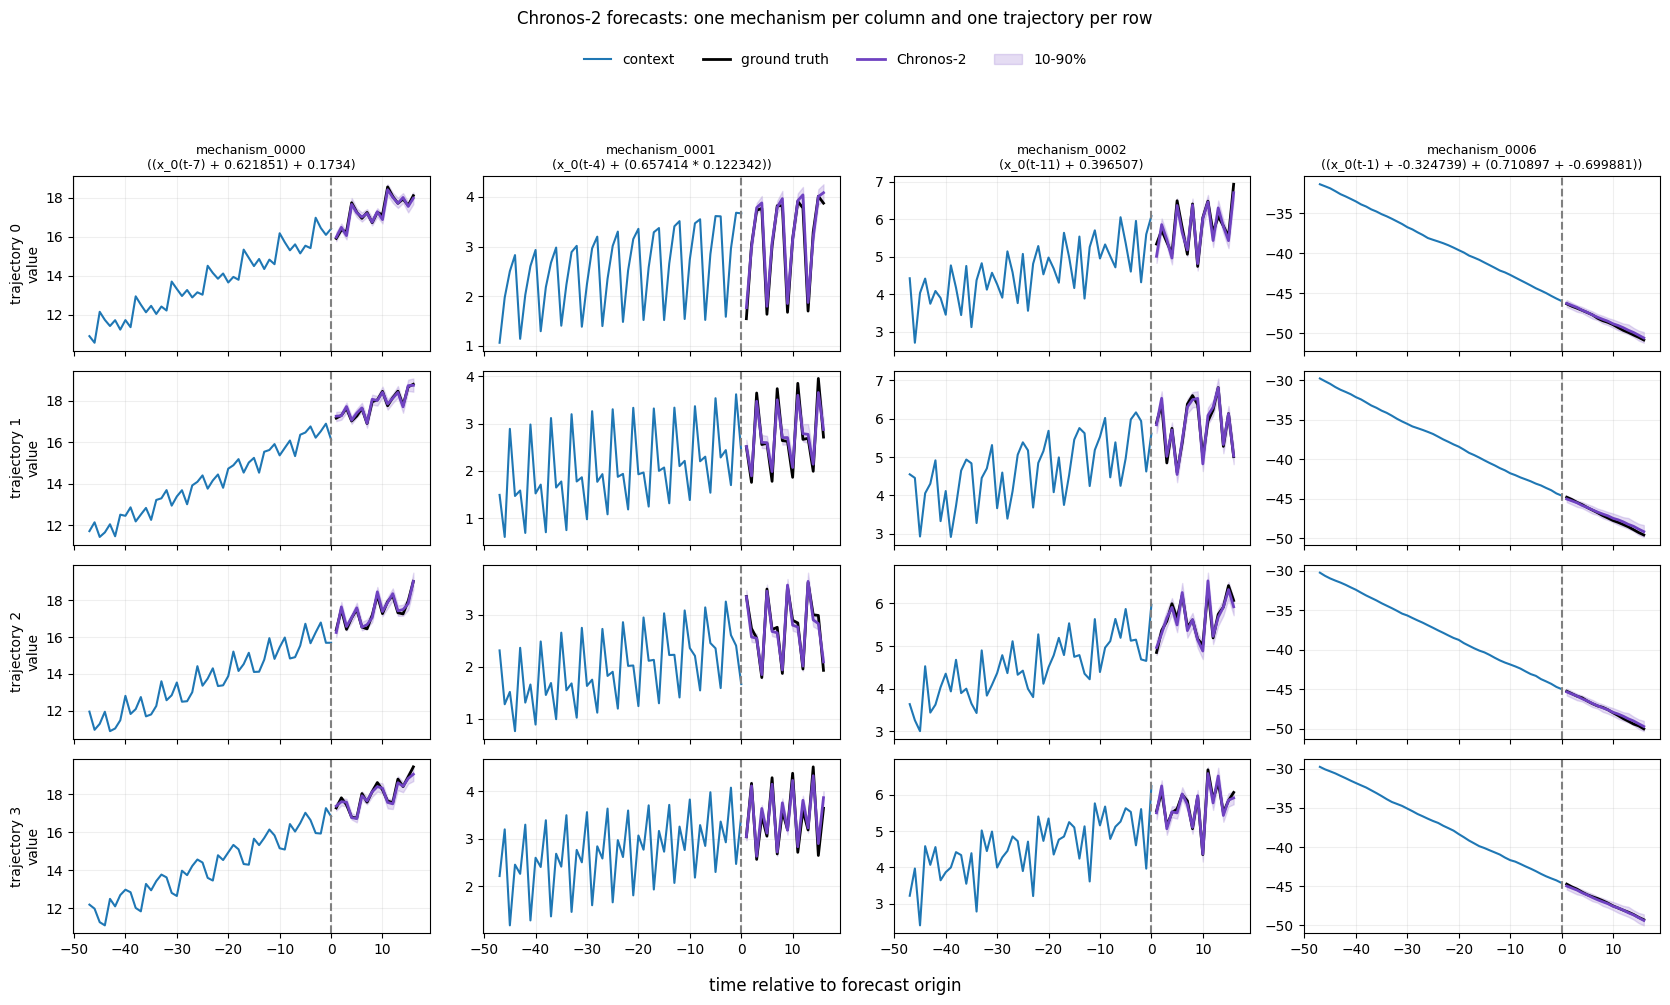

In [9]:
fig, axes = plt.subplots(
    len(trajectory_order),
    len(mechanism_order),
    figsize=(4.2 * len(mechanism_order), 2.5 * len(trajectory_order)),
    squeeze=False,
    sharex=True,
)
displayed_context = 48

for row, trajectory_index in enumerate(trajectory_order):
    for column, mechanism_id in enumerate(mechanism_order):
        axis = axes[row, column]
        position = batch_position.get((mechanism_id, trajectory_index))
        if position is None:
            axis.axis("off")
            continue

        axis.plot(
            context_axis[-displayed_context:],
            batch.past_values[position, -displayed_context:],
            label="context",
        )
        axis.plot(
            future_axis,
            batch.future_values[position],
            color="black",
            linewidth=2,
            label="ground truth",
        )
        axis.plot(
            future_axis,
            chronos_prediction[position],
            color="#6f42c1",
            linewidth=2,
            label="Chronos-2",
        )
        axis.fill_between(
            future_axis,
            chronos_lower[position],
            chronos_upper[position],
            color="#6f42c1",
            alpha=0.18,
            label="10-90%",
        )
        axis.axvline(0, color="0.5", linestyle="--")
        axis.grid(alpha=0.2)
        if row == 0:
            axis.set_title(
                f"{mechanism_id}\n{batch.formulas[position]}",
                fontsize=9,
            )
        if column == 0:
            axis.set_ylabel(f"trajectory {trajectory_index}\nvalue")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.965),
    ncol=4,
    frameon=False,
)
fig.suptitle(
    "Chronos-2 forecasts: one mechanism per column and one trajectory per row",
    y=0.995,
)
fig.supxlabel("time relative to forecast origin")
fig.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

**What this cell did.** It showed the Chronos-2 forecast for every trajectory in the batch. Reading down a column isolates variation between realizations of one mechanism; reading across a row compares different generating mechanisms under the same trajectory index.

## 6. Experiment record

In [10]:
from tsfmxai import __version__ as tsfmxai_version

package_versions = {
    "tsfmxai": f"{tsfmxai_version} (source tree)",
    **{
        name: importlib.metadata.version(name)
        for name in ["numpy", "pandas", "joblib", "torch", "chronos-forecasting"]
    },
}

metrics = {
    "accepted_job_count": len(job_results),
    "unique_generated_skeletons": int(job_summary["skeleton"].nunique()),
    "batch_size": batch.size,
    "batch_distinct_skeletons": batch.distinct_mechanism_count,
    "parallel_generation_seconds": parallel_generation_seconds,
    "sequential_generation_seconds": sequential_generation_seconds,
    "observed_generation_speedup": sequential_generation_seconds / parallel_generation_seconds,
    "parallel_equals_sequential": bool(same_mechanisms and same_trajectories),
    "chronos_model_load_seconds": model_load_seconds,
    "chronos_inference_seconds": chronos_inference_seconds,
    "chronos_mean_MAE": float(aggregate_metrics.loc["Chronos-2", "MAE"]),
    "chronos_mean_RMSE": float(aggregate_metrics.loc["Chronos-2", "RMSE"]),
    "chronos_mean_MASE": float(aggregate_metrics.loc["Chronos-2", "MASE"]),
    "last_value_mean_MAE": float(aggregate_metrics.loc["Last value", "MAE"]),
    "last_value_mean_RMSE": float(aggregate_metrics.loc["Last value", "RMSE"]),
    "last_value_mean_MASE": float(aggregate_metrics.loc["Last value", "MASE"]),
}

experiment_record = {
    "experiment_id": "abstract_syntax_tree_parallel_batch_chronos2_003",
    "status": "executed",
    "research_question": (
        "Can index-stable parallel jobs generate multiple trajectories per symbolic "
        "mechanism, assemble a batch with guaranteed mechanism diversity, and feed that "
        "batch to a forecasting foundation model without leaking generator metadata?"
    ),
    "hypothesis": (
        "Seeds derived from job coordinates will make results independent of worker order, "
        "and round-robin sampling over unique AST skeletons will enforce batch diversity."
    ),
    "configuration": {
        "root_seed": ROOT_SEED,
        "n_jobs": N_JOBS,
        "parallel_backend": "joblib-loky",
        "batch_size": BATCH_SIZE,
        "minimum_distinct_mechanisms": MINIMUM_DISTINCT_MECHANISMS,
        "tree": asdict(TREE_CONFIG),
        "generation": asdict(GENERATION_CONFIG),
        "forecast_model": {
            "model_id": MODEL_ID,
            "device": DEVICE,
            "dtype": "float32",
            "quantiles": [0.1, 0.5, 0.9],
            "model_batch_size": 8,
            "input_columns": ["item_id", "timestamp", "target"],
        },
    },
    "provenance": {
        "execution_date": "2026-09-29",
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "packages": package_versions,
        "hardware": "CPU",
        "seed_usage": (
            "Candidate and trajectory seeds derive from root seed, job index, attempt "
            "index, and stream; batch selection is deterministic."
        ),
        "implementation": [
            "src/tsfmxai/generators/random_expression.py",
            "src/tsfmxai/generators/trajectory.py",
            "src/tsfmxai/datasets/parallel_batch.py",
        ],
        "external_model_source": "https://huggingface.co/amazon/chronos-2",
        "official_api_source": (
            "https://github.com/amazon-science/chronos-forecasting/blob/main/"
            "src/chronos/chronos2/pipeline.py"
        ),
    },
    "metrics": metrics,
    "scientific_summary": (
        f"{len(job_results)} jobs produced {job_summary['skeleton'].nunique()} unique "
        f"skeletons; the {batch.size}-series batch retained "
        f"{batch.distinct_mechanism_count} distinct mechanisms. Parallel and sequential "
        f"outputs were exactly equal. Chronos-2 received only the {GENERATION_CONFIG.context_length} "
        f"historical target values per series and obtained mean MAE "
        f"{metrics['chronos_mean_MAE']:.4f} on the held-out "
        f"{GENERATION_CONFIG.prediction_length}-step futures."
    ),
    "reproduction_command": (
        ".venv\\Scripts\\python.exe -c \"from pathlib import Path; import nbformat; "
        "from nbclient import NotebookClient; p=Path(r'experiments/abstract_syntax_tree/"
        "3_parallel_jobs_batch_chronos2.ipynb'); n=nbformat.read(p, as_version=4); "
        "NotebookClient(n, timeout=1800, kernel_name='python3').execute(cwd=str(p.parent)); "
        "nbformat.write(n, p)\""
    ),
}
print(json.dumps(experiment_record, indent=2))

{
  "experiment_id": "abstract_syntax_tree_parallel_batch_chronos2_003",
  "status": "executed",
  "research_question": "Can index-stable parallel jobs generate multiple trajectories per symbolic mechanism, assemble a batch with guaranteed mechanism diversity, and feed that batch to a forecasting foundation model without leaking generator metadata?",
  "hypothesis": "Seeds derived from job coordinates will make results independent of worker order, and round-robin sampling over unique AST skeletons will enforce batch diversity.",
  "configuration": {
    "root_seed": 20260929,
    "n_jobs": 4,
    "parallel_backend": "joblib-loky",
    "batch_size": 16,
    "minimum_distinct_mechanisms": 4,
    "tree": {
      "minimum_operators": 1,
      "maximum_operators": 3,
      "num_series": 1,
      "minimum_lag": 1,
      "maximum_lag": 12,
      "parameter_probability": 0.55,
      "time_probability": 0.0,
      "lag_probability": 0.45,
      "add_probability": 0.8,
      "minimum_parameter_m

**What this cell did.** It stored the complete configuration, provenance, explicit seed policy, measured timings, forecast metrics, scientific conclusion, implementation paths, model source, and exact reproduction command inside the executed notebook.